# **Data Generation and Model Training**

In [ ]:
# ==========================================================
# TEST EXECUTION DATASET GENERATION (PART 1)
# AI-Driven Test Failure Prediction System
# ==========================================================

import pandas as pd
import numpy as np
import random
from datetime import datetime, timedelta

random.seed(42)
np.random.seed(42)

NUM_TESTS = 10000

modules = [
    "Login",
    "Payments",
    "Accounts",
    "Cards",
    "Loans",
    "Profile",
    "Transfers",
    "Investments"
]

features = [
    "Authentication",
    "Balance Check",
    "Fund Transfer",
    "Card Activation",
    "Loan Approval",
    "Bill Payment",
    "Beneficiary Management",
    "Statement Download"
]

browsers = [
    "Chrome",
    "Firefox",
    "Edge"
]

environments = [
    "DEV",
    "SIT",
    "UAT",
    "PROD"
]

criticality_levels = [
    "High",
    "Medium",
    "Low"
]

automation_types = [
    "Smoke",
    "Regression",
    "Sanity",
    "Functional"
]

start_date = datetime(2025,1,1)

records = []

for i in range(NUM_TESTS):

    test_id = f"TC{i+1:05d}"

    module = random.choice(modules)

    feature = random.choice(features)

    browser = random.choice(browsers)

    environment = random.choices(

        environments,

        weights=[20,30,30,20],

        k=1

    )[0]

    automation_type = random.choice(automation_types)

    business_criticality = random.choices(

        criticality_levels,

        weights=[30,45,25],

        k=1

    )[0]

    # ======================================================
    # MODULE COMPLEXITY
    # ======================================================

    if module in ["Payments","Transfers"]:

        complexity = 9

    elif module in ["Loans","Cards"]:

        complexity = 7

    elif module in ["Accounts","Investments"]:

        complexity = 6

    else:

        complexity = 4

    # ======================================================
    # DEVELOPER ACTIVITY
    # ======================================================

    commit_count = np.random.randint(

        max(2, complexity),

        complexity * 4

    )

    code_churn = int(

        commit_count *

        np.random.normal(18,4)

    )

    code_churn = np.clip(

        code_churn,

        20,

        500

    )

    # ======================================================
    # EXECUTION TIME
    # ======================================================

    execution_time = np.random.normal(

        complexity,

        1.5

    )

    execution_time = round(

        np.clip(

            execution_time,

            2,

            18

        ),

        2

    )

    # ======================================================
    # TEST COVERAGE
    # ======================================================

    if environment=="DEV":

        coverage = np.random.normal(72,8)

    elif environment=="SIT":

        coverage = np.random.normal(80,6)

    elif environment=="UAT":

        coverage = np.random.normal(87,5)

    else:

        coverage = np.random.normal(91,4)

    coverage = round(

        np.clip(

            coverage,

            55,

            99

        ),

        2

    )

    # ======================================================
    # FAILURE HISTORY
    # ======================================================

    expected_failures = (

        complexity/2

        +

        code_churn/250

        -

        coverage/40

    )

    failure_count = np.random.poisson(

        max(expected_failures,0.5)

    )

    failure_count = int(

        np.clip(

            failure_count,

            0,

            10

        )

    )

    # ======================================================
    # RETRIES
    # ======================================================

    retry_count = np.random.poisson(

        failure_count/4

    )

    retry_count = int(

        np.clip(

            retry_count,

            0,

            3

        )

    )

    # ======================================================
    # EXECUTION DATE
    # ======================================================

    execution_date = (

        start_date +

        timedelta(

            days=random.randint(0,180)

        )

    )

    records.append([

        test_id,

        module,

        feature,

        browser,

        environment,

        automation_type,

        execution_time,

        failure_count,

        retry_count,

        code_churn,

        commit_count,

        coverage,

        complexity,

        business_criticality,

        execution_date

    ])

# ==========================================================
# DATAFRAME
# ==========================================================

df = pd.DataFrame(

    records,

    columns=[

        "test_id",

        "module",

        "feature",

        "browser",

        "environment",

        "automation_type",

        "execution_time",

        "failure_count",

        "retry_count",

        "code_churn",

        "commit_count",

        "test_coverage",

        "module_complexity",

        "business_criticality",

        "execution_date"

    ]

)

print("Dataset Shape :", df.shape)

print(df.head())

print("\nSummary")

print(df.describe())

print("\nMissing Values")

print(df.isnull().sum())

Dataset Shape : (10000, 15)
   test_id    module                 feature browser environment  \
0  TC00001  Payments          Authentication    Edge         SIT   
1  TC00002  Payments  Beneficiary Management  Chrome         DEV   
2  TC00003     Login         Card Activation    Edge         UAT   
3  TC00004     Loans          Authentication  Chrome         UAT   
4  TC00005   Profile           Balance Check  Chrome         SIT   

  automation_type  execution_time  failure_count  retry_count  code_churn  \
0      Regression            9.77              2            0         236   
1      Regression            8.13              3            0         375   
2      Functional            3.82              0            0         222   
3          Sanity            6.18              2            3         388   
4          Sanity            2.83              1            0         120   

   commit_count  test_coverage  module_complexity business_criticality  \
0            15          8

In [ ]:
# ==========================================================
# PART 2 (VERSION 2)
# FEATURE ENGINEERING + TARGET GENERATION
# ==========================================================

import numpy as np
import pandas as pd

# ==========================================================
# DATE FEATURES
# ==========================================================

df["execution_date"] = pd.to_datetime(df["execution_date"])

df["year"] = df["execution_date"].dt.year
df["month"] = df["execution_date"].dt.month
df["day"] = df["execution_date"].dt.day
df["week_of_year"] = df["execution_date"].dt.isocalendar().week.astype(int)
df["day_of_week"] = df["execution_date"].dt.day_name()

# ==========================================================
# FEATURE ENGINEERING
# ==========================================================

df["failure_rate"] = df["failure_count"] / (df["failure_count"] + 1)

df["retry_ratio"] = df["retry_count"] / (df["failure_count"] + 1)

df["execution_efficiency"] = (
    df["test_coverage"] /
    df["execution_time"]
)

df["change_density"] = (
    df["code_churn"] /
    (df["commit_count"] + 1)
)

df["stability_index"] = (
    df["test_coverage"]
    - df["failure_count"]*5
    - df["retry_count"]*4
)

automation_map = {
    "Smoke":95,
    "Sanity":90,
    "Regression":84,
    "Functional":78
}

df["automation_efficiency"] = (
    df["automation_type"].map(automation_map)
)

df["high_churn_flag"] = (
    df["code_churn"] > 260
).astype(int)

df["retry_flag"] = (
    df["retry_count"] >= 2
).astype(int)

df["low_coverage_flag"] = (
    df["test_coverage"] < 75
).astype(int)

df["high_failure_history"] = (
    df["failure_count"] >= 5
).astype(int)

df["coverage_category"] = pd.cut(
    df["test_coverage"],
    bins=[0,70,85,100],
    labels=["Low","Medium","High"]
)

df["execution_category"] = pd.cut(
    df["execution_time"],
    bins=[0,5,8,20],
    labels=["Fast","Medium","Slow"]
)

# ==========================================================
# RISK SCORE
# ==========================================================

risk_score = (

      df["failure_count"] * 2.8

    + df["retry_count"] * 2.5

    + df["module_complexity"] * 1.6

    + df["code_churn"] / 28

    + df["high_churn_flag"] * 4

    + df["high_failure_history"] * 4

    - df["test_coverage"] / 4

    - df["automation_efficiency"] / 8

)

risk_score += np.where(
    df["environment"]=="PROD",
    2,
    0
)

risk_score += np.where(
    df["business_criticality"]=="High",
    2,
    0
)

risk_score += np.where(
    df["module"].isin(["Payments","Transfers"]),
    3,
    0
)

# Small realistic noise
risk_score += np.random.normal(
    0,
    1.2,
    len(df)
)

# ==========================================================
# SIGMOID CONVERSION
# ==========================================================

failure_probability = 1 / (
    1 +
    np.exp(
        -(risk_score-9)/3
    )
)

failure_probability = np.clip(
    failure_probability,
    0.03,
    0.97
)

# ==========================================================
# TARGET
# ==========================================================

status = np.where(

    np.random.rand(len(df))
    <
    failure_probability,

    "FAIL",

    "PASS"

)

df["status"] = status

# ==========================================================
# ROOT CAUSE
# ==========================================================

root_causes = []

for _, row in df.iterrows():

    if row["status"] == "PASS":

        root_causes.append("NA")

    else:

        if row["module"] in ["Payments","Transfers"]:

            root_causes.append(

                np.random.choice(

                    [
                        "API",
                        "Database",
                        "Infrastructure"
                    ],

                    p=[0.45,0.35,0.20]

                )

            )

        elif row["module"]=="Login":

            root_causes.append(

                np.random.choice(

                    [
                        "UI",
                        "API",
                        "Configuration"
                    ],

                    p=[0.50,0.30,0.20]

                )

            )

        else:

            root_causes.append(

                np.random.choice(

                    [
                        "UI",
                        "API",
                        "Database",
                        "Configuration"
                    ],

                    p=[0.35,0.30,0.20,0.15]

                )

            )

df["root_cause"] = root_causes

# ==========================================================
# ENCODING
# ==========================================================

df["status_encoded"] = (
    df["status"]
      .map({
          "PASS":0,
          "FAIL":1
      })
)

root_map = {
    "NA":0,
    "UI":1,
    "API":2,
    "Database":3,
    "Infrastructure":4,
    "Configuration":5
}

df["root_cause_encoded"] = (
    df["root_cause"]
      .map(root_map)
)

# ==========================================================
# SUMMARY
# ==========================================================

print("="*60)
print("STATUS DISTRIBUTION")
print("="*60)

print(df["status"].value_counts())
print()

print(df["status"].value_counts(normalize=True))

print("\nAverage Failure Probability")
print(round(failure_probability.mean(),3))

print("\nRisk Score Summary")
print(pd.Series(risk_score).describe())

print("\nFeature Engineering Completed Successfully")

STATUS DISTRIBUTION
status
PASS    6876
FAIL    3124
Name: count, dtype: int64

status
PASS    0.6876
FAIL    0.3124
Name: proportion, dtype: float64

Average Failure Probability
0.309

Risk Score Summary
count    10000.000000
mean         0.888867
std         15.349168
min        -29.576388
25%        -11.687885
50%         -0.727394
75%         11.229105
max         50.735120
dtype: float64

Feature Engineering Completed Successfully


In [ ]:
# ==========================================================
# PART 3
# DATA VALIDATION & EXPORT
# ==========================================================

print("=" * 60)
print("TEST EXECUTION DATASET SUMMARY")
print("=" * 60)

# ==========================================================
# DATASET INFORMATION
# ==========================================================

print("\nDataset Shape")
print(df.shape)

print("\nColumn Names")
print(df.columns.tolist())

print("\nData Types")
print(df.dtypes)

print("\nMissing Values")
print(df.isnull().sum())

print("\nDuplicate Records")
print(df.duplicated().sum())

# ==========================================================
# TARGET DISTRIBUTION
# ==========================================================

print("\nStatus Distribution")
print(df["status"].value_counts())

print("\nStatus Percentage")
print(
    round(
        df["status"].value_counts(normalize=True) * 100,
        2
    )
)

# ==========================================================
# ROOT CAUSE DISTRIBUTION
# ==========================================================

print("\nRoot Cause Distribution")
print(df["root_cause"].value_counts())

# ==========================================================
# CATEGORICAL FEATURES
# ==========================================================

categorical_columns = [

    "module",

    "feature",

    "browser",

    "environment",

    "automation_type",

    "business_criticality",

    "coverage_category",

    "execution_category"

]

for col in categorical_columns:

    print(f"\n{col}")

    print(df[col].value_counts())

# ==========================================================
# NUMERIC SUMMARY
# ==========================================================

print("\nNumeric Summary")

print(

    df.describe().round(2)

)

# ==========================================================
# CORRELATION MATRIX
# ==========================================================

numeric_columns = [

    "execution_time",

    "failure_count",

    "retry_count",

    "code_churn",

    "commit_count",

    "test_coverage",

    "module_complexity",

    "failure_rate",

    "retry_ratio",

    "execution_efficiency",

    "change_density",

    "stability_index",

    "automation_efficiency",

    "high_churn_flag",

    "retry_flag",

    "low_coverage_flag",

    "high_failure_history",

    "status_encoded"

]

correlation_matrix = df[

    numeric_columns

].corr()

print("\nCorrelation Matrix")

print(

    correlation_matrix.round(2)

)

# ==========================================================
# FEATURE CORRELATION WITH TARGET
# ==========================================================

print("\nFeature Correlation With Target")

target_corr = (

    correlation_matrix["status_encoded"]

    .sort_values(

        ascending=False

    )

)

print(target_corr)

# ==========================================================
# EXPORT DATASETS
# ==========================================================

raw_columns = [

    "test_id",

    "module",

    "feature",

    "browser",

    "environment",

    "automation_type",

    "execution_time",

    "failure_count",

    "retry_count",

    "code_churn",

    "commit_count",

    "test_coverage",

    "module_complexity",

    "business_criticality",

    "status",

    "root_cause",

    "execution_date"

]

df[raw_columns].to_csv(

    "test_execution_history.csv",

    index=False

)

df.to_csv(

    "test_execution_feature_engineered.csv",

    index=False

)

print("\nDatasets Exported Successfully")

print("Saved : test_execution_history.csv")

print("Saved : test_execution_feature_engineered.csv")

# ==========================================================
# FINAL PREVIEW
# ==========================================================

print("\nFirst Five Records")

print(df.head())

print("\nTotal Columns :", len(df.columns))

print("\nDataset Generation Completed Successfully")

TEST EXECUTION DATASET SUMMARY

Dataset Shape
(10000, 36)

Column Names
['test_id', 'module', 'feature', 'browser', 'environment', 'automation_type', 'execution_time', 'failure_count', 'retry_count', 'code_churn', 'commit_count', 'test_coverage', 'module_complexity', 'business_criticality', 'execution_date', 'year', 'month', 'day', 'week_of_year', 'day_of_week', 'failure_rate', 'retry_ratio', 'execution_efficiency', 'change_density', 'stability_index', 'automation_efficiency', 'high_churn_flag', 'retry_flag', 'low_coverage_flag', 'high_failure_history', 'coverage_category', 'execution_category', 'status', 'root_cause', 'status_encoded', 'root_cause_encoded']

Data Types
test_id                          object
module                           object
feature                          object
browser                          object
environment                      object
automation_type                  object
execution_time                  float64
failure_count                     int64
r

In [ ]:
print(df[["status","status_encoded"]].drop_duplicates())

  status  status_encoded
0   PASS               0
1   FAIL               1


Dataset Loaded Successfully
(10000, 36)

Features Used
['module', 'feature', 'browser', 'environment', 'automation_type', 'execution_time', 'failure_count', 'retry_count', 'code_churn', 'commit_count', 'test_coverage', 'module_complexity', 'business_criticality', 'year', 'month', 'day', 'week_of_year', 'day_of_week', 'execution_efficiency', 'change_density', 'stability_index', 'automation_efficiency', 'high_churn_flag', 'retry_flag', 'low_coverage_flag', 'high_failure_history', 'coverage_category', 'execution_category']

Encoded Shape
(10000, 53)

Training Samples : 8000
Testing Samples : 2000

Training Model...
Fitting 3 folds for each of 32 candidates, totalling 96 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [05:59:59] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Best Parameters
{'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 300, 'subsample': 0.8}

Accuracy
89.9 %

Classification Report
              precision    recall  f1-score   support

           0       0.93      0.92      0.93      1375
           1       0.83      0.85      0.84       625

    accuracy                           0.90      2000
   macro avg       0.88      0.89      0.88      2000
weighted avg       0.90      0.90      0.90      2000



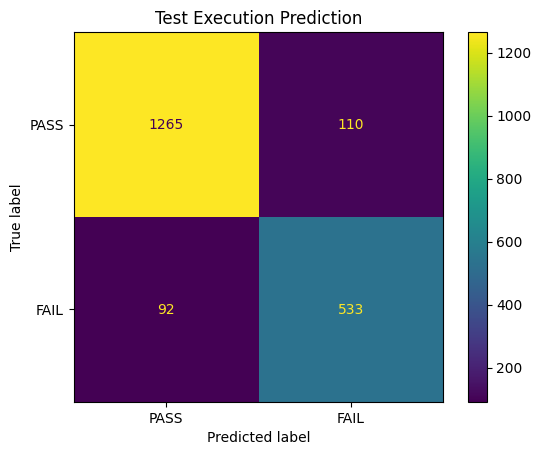


Top 20 Important Features
                           Feature  Importance
1                    failure_count    0.330850
6                module_complexity    0.059523
3                       code_churn    0.056517
2                      retry_count    0.021683
13                 stability_index    0.019987
22                    module_Login    0.016587
35                environment_PROD    0.015870
27  feature_Beneficiary Management    0.015538
24                  module_Profile    0.015208
14           automation_efficiency    0.015076
4                     commit_count    0.014890
51       execution_category_Medium    0.014346
41        business_criticality_Low    0.013855
11            execution_efficiency    0.013795
42     business_criticality_Medium    0.013596
0                   execution_time    0.013401
12                  change_density    0.013302
37                 environment_UAT    0.013235
5                    test_coverage    0.013164
29         feature_Card Activatio

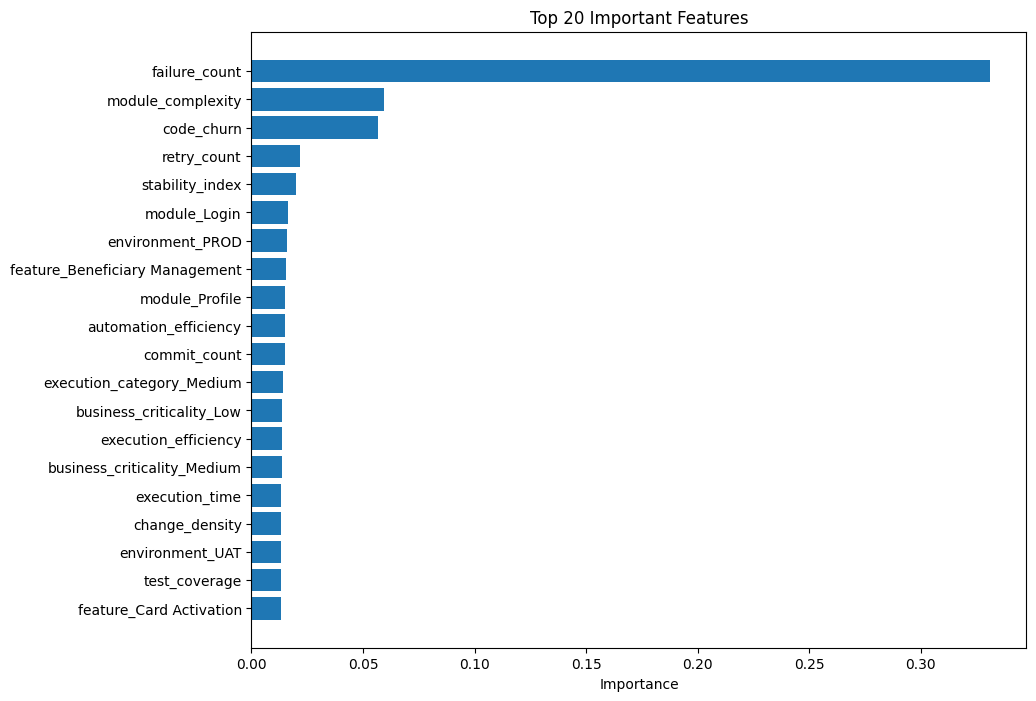


Model Saved Successfully

Predictions Saved Successfully
Saved : test_execution_predictions.csv

Test Execution Model Completed Successfully


In [ ]:
# ==========================================================
# PART 4
# TEST EXECUTION XGBOOST MODEL TRAINING
# ==========================================================

import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from xgboost import XGBClassifier

# ==========================================================
# LOAD DATA
# ==========================================================

df = pd.read_csv("test_execution_feature_engineered.csv")

print("Dataset Loaded Successfully")
print(df.shape)

# ==========================================================
# TARGET
# ==========================================================

target = "status_encoded"

# ==========================================================
# REMOVE LEAKAGE FEATURES
# ==========================================================

drop_columns = [
    "test_id",
    "execution_date",
    "status",
    "status_encoded",
    "root_cause",
    "root_cause_encoded",
    "failure_rate",
    "retry_ratio"
]
X = df.drop(columns=drop_columns)

y = df[target]

print("\nFeatures Used")

print(X.columns.tolist())

# ==========================================================
# ONE HOT ENCODING
# ==========================================================

categorical_columns = X.select_dtypes(include="object").columns

X = pd.get_dummies(

    X,

    columns=categorical_columns,

    drop_first=True

)

print("\nEncoded Shape")

print(X.shape)

# ==========================================================
# TRAIN TEST SPLIT
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42,

    stratify=y

)

print("\nTraining Samples :", len(X_train))
print("Testing Samples :", len(X_test))

# ==========================================================
# XGBOOST MODEL
# ==========================================================
fail_count = sum(y_train == 1)
pass_count = sum(y_train == 0)

scale_weight = pass_count / fail_count
model = XGBClassifier(

    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    scale_pos_weight=scale_weight,
    use_label_encoder=False

)

# ==========================================================
# HYPERPARAMETER TUNING
# ==========================================================

param_grid = {

    "max_depth":[4,6],

    "learning_rate":[0.05,0.10],

    "n_estimators":[200,300],

    "subsample":[0.8,1.0],

    "colsample_bytree":[0.8,1.0]

}

grid = GridSearchCV(

    estimator=model,

    param_grid=param_grid,

    cv=3,

    scoring="f1_weighted",

    n_jobs=-1,

    verbose=1

)

print("\nTraining Model...")

grid.fit(X_train,y_train)

best_model = grid.best_estimator_

print("\nBest Parameters")

print(grid.best_params_)

# ==========================================================
# PREDICTIONS
# ==========================================================

predictions = best_model.predict(X_test)

# ==========================================================
# MODEL EVALUATION
# ==========================================================

accuracy = accuracy_score(

    y_test,

    predictions

)

print("\nAccuracy")

print(round(accuracy*100,2),"%")

print("\nClassification Report")

print(

    classification_report(

        y_test,

        predictions

    )

)

# ==========================================================
# CONFUSION MATRIX
# ==========================================================

cm = confusion_matrix(

    y_test,

    predictions

)

disp = ConfusionMatrixDisplay(

    confusion_matrix=cm,

    display_labels=[

        "PASS",

        "FAIL"

    ]

)

disp.plot()

plt.title("Test Execution Prediction")

plt.show()

# ==========================================================
# FEATURE IMPORTANCE
# ==========================================================

importance = pd.DataFrame({

    "Feature":X.columns,

    "Importance":best_model.feature_importances_

})

importance = importance.sort_values(

    by="Importance",

    ascending=False

)

print("\nTop 20 Important Features")

print(

    importance.head(20)

)

plt.figure(figsize=(10,8))

plt.barh(

    importance.head(20)["Feature"],

    importance.head(20)["Importance"]

)

plt.gca().invert_yaxis()

plt.xlabel("Importance")

plt.title("Top 20 Important Features")

plt.show()

# ==========================================================
# SAVE MODEL
# ==========================================================

joblib.dump(

    best_model,

    "best_test_execution_xgb_model.pkl"

)

joblib.dump(

    X.columns,

    "test_execution_features.pkl"

)

print("\nModel Saved Successfully")

# ==========================================================
# SAVE PREDICTIONS
# ==========================================================

prediction_df = pd.DataFrame({

    "Actual":y_test,

    "Predicted":predictions

})

prediction_df.to_csv(

    "test_execution_predictions.csv",

    index=False

)

print("\nPredictions Saved Successfully")

print("Saved : test_execution_predictions.csv")

print("\nTest Execution Model Completed Successfully")

### Random Forest Classifier Training


Training Random Forest Model...
Fitting 3 folds for each of 81 candidates, totalling 243 fits

Best Parameters for Random Forest:
{'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 300}

Random Forest Accuracy: 90.5%

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.93      0.93      1375
           1       0.85      0.84      0.85       625

    accuracy                           0.91      2000
   macro avg       0.89      0.89      0.89      2000
weighted avg       0.90      0.91      0.90      2000



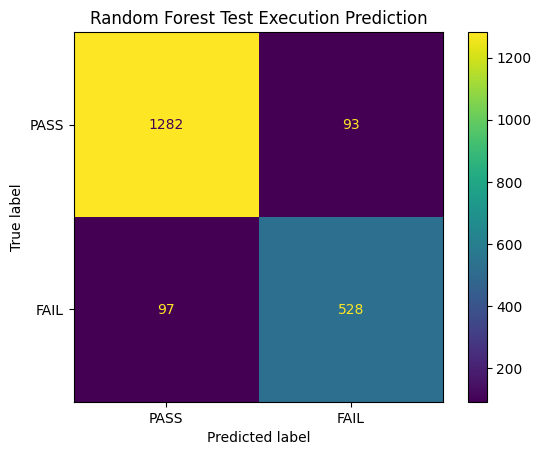


Top 20 Important Features (Random Forest):
                    Feature  Importance
3                code_churn    0.133408
1             failure_count    0.130422
13          stability_index    0.106539
4              commit_count    0.088558
15          high_churn_flag    0.073094
6         module_complexity    0.068910
18     high_failure_history    0.053375
11     execution_efficiency    0.038381
0            execution_time    0.036278
2               retry_count    0.031029
12           change_density    0.030654
5             test_coverage    0.026698
9                       day    0.017911
10             week_of_year    0.016200
23          module_Payments    0.013036
25         module_Transfers    0.011944
16               retry_flag    0.010879
52  execution_category_Slow    0.009315
8                     month    0.009067
14    automation_efficiency    0.008284


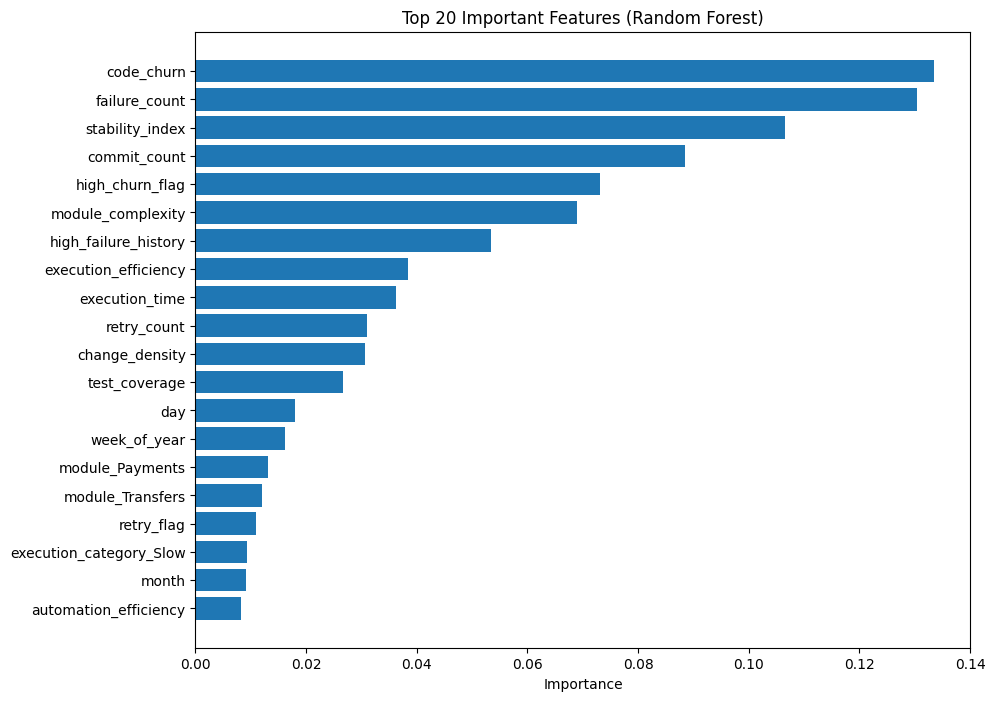


Random Forest Model Saved Successfully


In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Initialize Random Forest Classifier
rf_model = RandomForestClassifier(random_state=42, class_weight='balanced')

# Define parameter grid for GridSearchCV
rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Set up GridSearchCV
rf_grid = GridSearchCV(
    estimator=rf_model,
    param_grid=rf_param_grid,
    cv=3,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)

print("\nTraining Random Forest Model...")
rf_grid.fit(X_train, y_train)

rf_best_model = rf_grid.best_estimator_

print("\nBest Parameters for Random Forest:")
print(rf_grid.best_params_)

# Make predictions
rf_predictions = rf_best_model.predict(X_test)

# Evaluate the model
rf_accuracy = accuracy_score(y_test, rf_predictions)
print(f"\nRandom Forest Accuracy: {round(rf_accuracy * 100, 2)}%")
print("\nRandom Forest Classification Report:")
print(classification_report(y_test, rf_predictions))

# Confusion Matrix
rf_cm = confusion_matrix(y_test, rf_predictions)
rf_disp = ConfusionMatrixDisplay(
    confusion_matrix=rf_cm,
    display_labels=["PASS", "FAIL"]
)
rf_disp.plot()
plt.title("Random Forest Test Execution Prediction")
plt.show()

# Feature Importance
rf_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_best_model.feature_importances_
})
rf_importance = rf_importance.sort_values(
    by="Importance",
    ascending=False
)

print("\nTop 20 Important Features (Random Forest):")
print(rf_importance.head(20))

plt.figure(figsize=(10, 8))
plt.barh(
    rf_importance.head(20)["Feature"],
    rf_importance.head(20)["Importance"]
)
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.title("Top 20 Important Features (Random Forest)")
plt.show()

# Save the best Random Forest model
joblib.dump(
    rf_best_model,
    "best_test_execution_rf_model.pkl"
)
print("\nRandom Forest Model Saved Successfully")

In [ ]:
joblib.dump(
    X.columns,
    "test_execution_Feature_rf.pkl"
)
print("Random Forest features saved to test_execution_Feature_rf.pkl")

Random Forest features saved to test_execution_Feature_rf.pkl


### Support Vector Machine (SVM) Classifier Training


Training SVM Model...
Fitting 3 folds for each of 12 candidates, totalling 36 fits

Best Parameters for SVM:
{'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}

SVM Accuracy: 88.5%

SVM Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.88      0.91      1385
           1       0.77      0.89      0.83       615

    accuracy                           0.89      2000
   macro avg       0.86      0.89      0.87      2000
weighted avg       0.89      0.89      0.89      2000



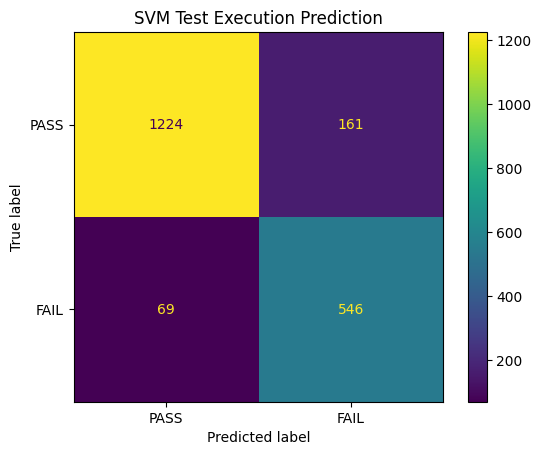


SVM Model Saved Successfully


In [ ]:
from sklearn.svm import SVC

# Initialize SVM Classifier
# Using a linear kernel for better interpretability and faster computation on high-dimensional data.
# 'balanced' mode automatically adjusts weights inversely proportional to class frequencies.
svm_model = SVC(random_state=42, class_weight='balanced', probability=True) # probability=True for consistent API with other models

# Define parameter grid for GridSearchCV
# Starting with a smaller grid for SVM due to higher computational cost
svm_param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'], # Experiment with linear and RBF kernels
    'gamma': ['scale', 'auto'] # Kernel coefficient for 'rbf', 'poly' and 'sigmoid'
}

# Set up GridSearchCV
svm_grid = GridSearchCV(
    estimator=svm_model,
    param_grid=svm_param_grid,
    cv=3,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)

print("\nTraining SVM Model...")
svm_grid.fit(X_train, y_train)

svm_best_model = svm_grid.best_estimator_

print("\nBest Parameters for SVM:")
print(svm_grid.best_params_)

# Make predictions
svm_predictions = svm_best_model.predict(X_test)

# Evaluate the model
svm_accuracy = accuracy_score(y_test, svm_predictions)
print(f"\nSVM Accuracy: {round(svm_accuracy * 100, 2)}%")
print("\nSVM Classification Report:")
print(classification_report(y_test, svm_predictions))

# Confusion Matrix
svm_cm = confusion_matrix(y_test, svm_predictions)
svm_disp = ConfusionMatrixDisplay(
    confusion_matrix=svm_cm,
    display_labels=["PASS", "FAIL"]
)
svm_disp.plot()
plt.title("SVM Test Execution Prediction")
plt.show()

# Note: Feature importance for SVMs (especially with non-linear kernels) is not as directly
# available as with tree-based models like RandomForest or XGBoost.
# For linear kernels, `coef_` can be used to infer importance.
# For non-linear kernels, more complex methods like permutation importance are needed.
# Since the request was to train 'similarly', I'm omitting a direct feature importance plot for now.

# Save the best SVM model
joblib.dump(
    svm_best_model,
    "best_test_execution_svm_model.pkl"
)
print("\nSVM Model Saved Successfully")

### Model Comparison: Accuracy Bar Graph

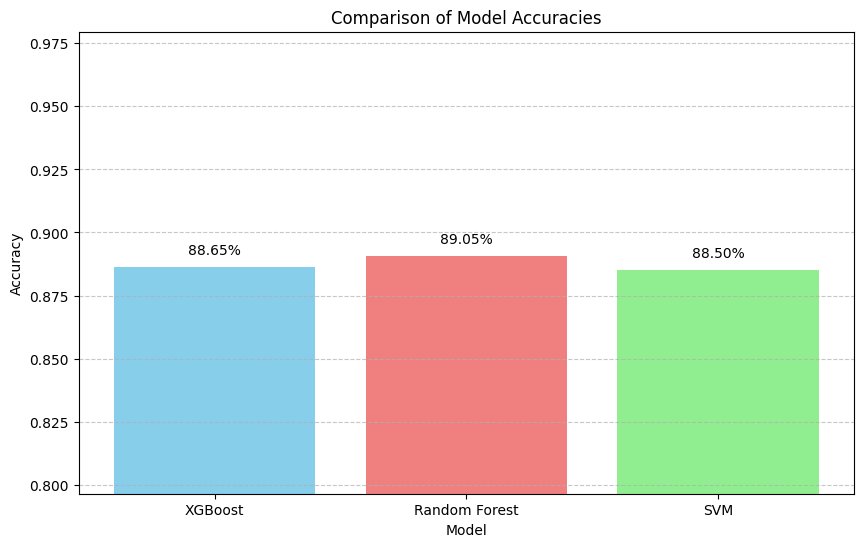

In [ ]:
import matplotlib.pyplot as plt

# Model accuracies (assuming these variables are still in scope or re-calculated/loaded)
# If running this cell independently, ensure accuracy variables are defined or loaded.
xgb_accuracy = accuracy # From XGBoost section
rf_accuracy = rf_accuracy # From Random Forest section
svm_accuracy = svm_accuracy # From SVM section

model_names = ['XGBoost', 'Random Forest', 'SVM']
accuracies = [xgb_accuracy, rf_accuracy, svm_accuracy]

plt.figure(figsize=(10, 6))
plt.bar(model_names, accuracies, color=['skyblue', 'lightcoral', 'lightgreen'])
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.title('Comparison of Model Accuracies')
plt.ylim(min(accuracies) * 0.9, max(accuracies) * 1.1) # Adjust y-axis for better visualization
for i, acc in enumerate(accuracies):
    plt.text(i, acc + 0.005, f'{acc:.2%}', ha='center')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()